In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import missingno as msno
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


<Axes: >

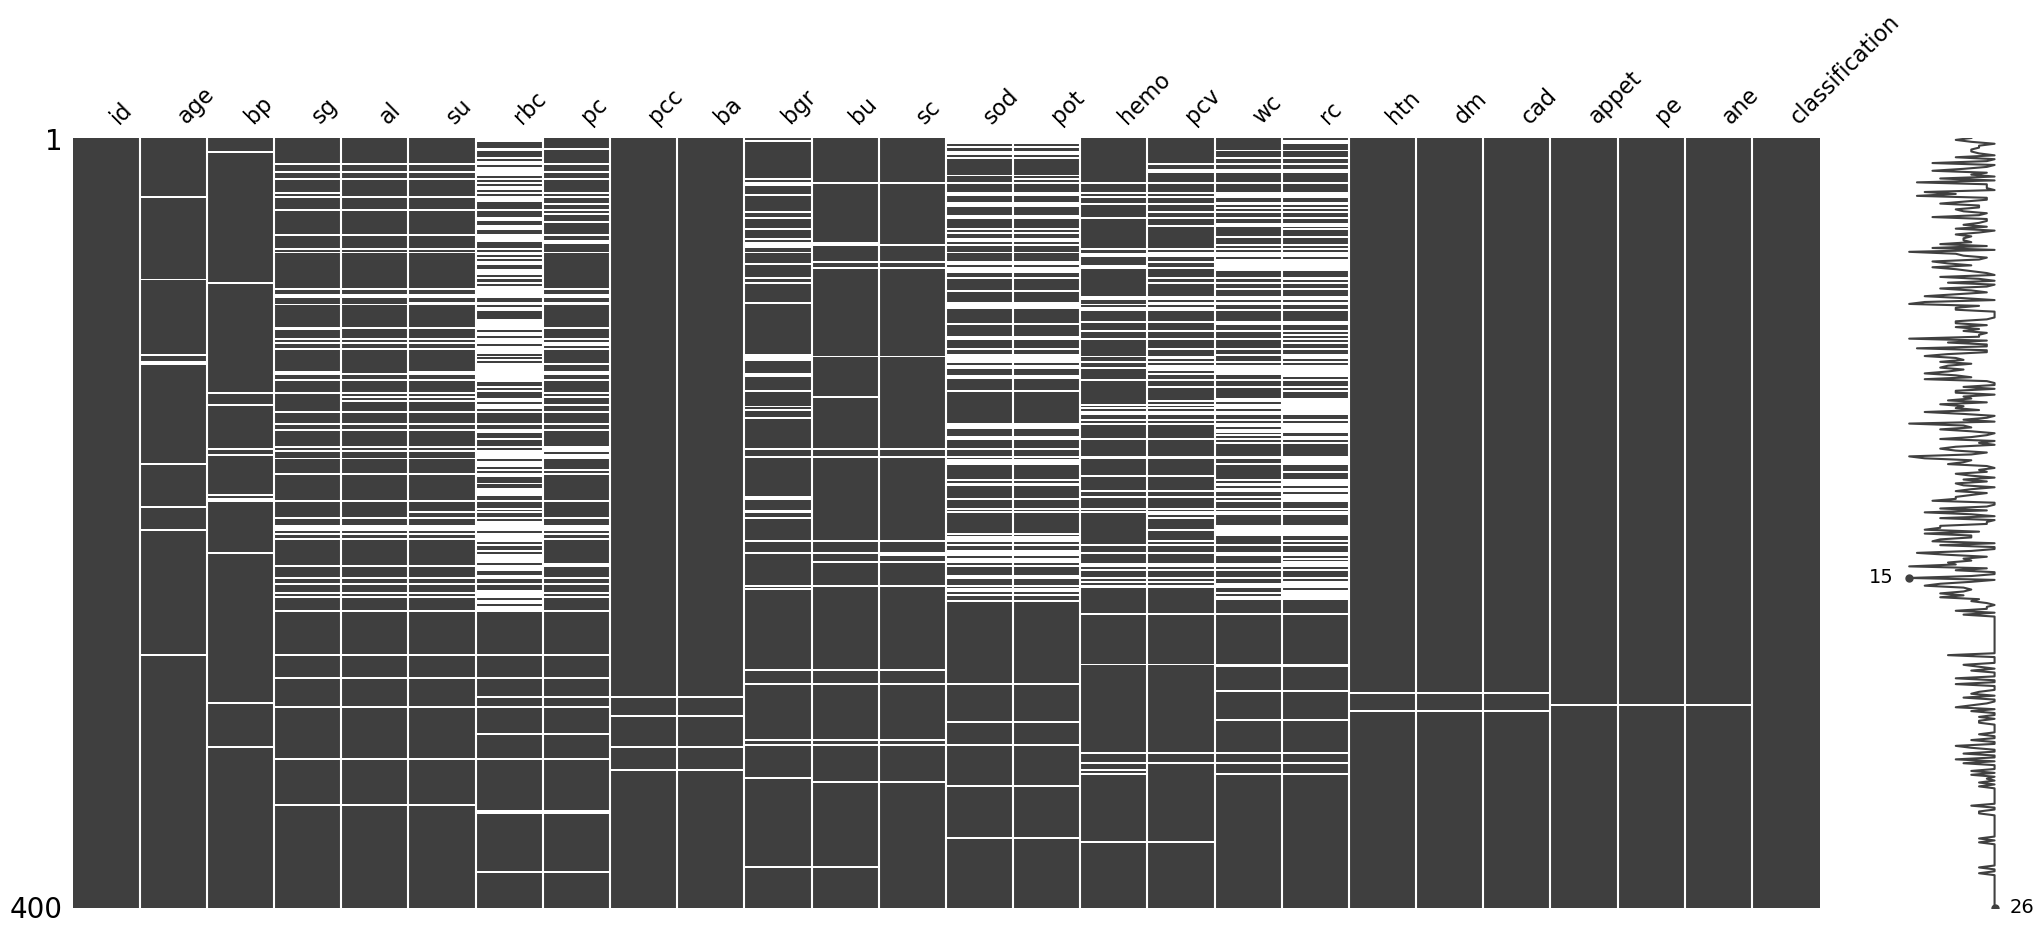

In [3]:
msno.matrix(df)

In [4]:
# Removes tab from start and end of each value 
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# Replace all '?' values in the DataFrame with NaN
df = df.replace('?', np.nan)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             329 non-null    object 
 17  wc              294 non-null    obj

In [6]:
df.dropna(subset=['rc','rbc','wc'],how='all',inplace=True)
df.dropna(subset=['sod','pot'],how='all',inplace=True)

In [7]:
for i in df.select_dtypes(include=['object']):
    print(f"{i}"," :",df[i].isna().sum())

rbc  : 58
pc  : 31
pcc  : 4
ba  : 4
pcv  : 19
wc  : 26
rc  : 34
htn  : 2
dm  : 2
cad  : 2
appet  : 1
pe  : 1
ane  : 1
classification  : 0


In [8]:
numeric = list(df.select_dtypes(exclude=['object']))
categories = list(df.select_dtypes(include=['object']))


In [9]:
df[numeric]

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
3,3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2
5,5,60.0,90.0,1.015,3.0,0.0,74.0,25.0,1.1,142.0,3.2,12.2
9,9,53.0,90.0,1.020,2.0,0.0,70.0,107.0,7.2,114.0,3.7,9.5
11,11,63.0,70.0,1.010,3.0,0.0,380.0,60.0,2.7,131.0,4.2,10.8
12,12,68.0,70.0,1.015,3.0,1.0,208.0,72.0,2.1,138.0,5.8,9.7
...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,0.5,150.0,4.9,15.7
396,396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,1.2,141.0,3.5,16.5
397,397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,0.6,137.0,4.4,15.8
398,398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,1.0,135.0,4.9,14.2


In [10]:
for i in categories:
    df[i] = df[i].fillna(df[i].mode()[0])

# Fill numeric columns with median
for i in numeric:
    df[i] = df[i].fillna(df[i].median())

In [11]:
df['rc']=df['rc'].astype('float64')
df['pcv']=df['pcv'].astype('int64')
df['wc']=df['wc'].astype('int64')

In [12]:

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

for col in categories:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
# Example: assume your target column is 'class' (CKD vs not CKD)
X = df.drop(['classification','id'], axis=1)   # Features
y = df['classification']                # Target

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit model
rf.fit(X_train, y_train)

# Evaluate
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))


Train Accuracy: 1.0
Test Accuracy: 1.0


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Predictions
y_pred = rf.predict(X_test)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Precision, Recall, F1 (macro averages across classes)
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1-score:", f1_score(y_test, y_pred, average='macro'))

# Full classification report (per class + averages)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[26  0]
 [ 0 29]]
Precision: 1.0
Recall: 1.0
F1-score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        29

    accuracy                           1.00        55
   macro avg       1.00      1.00      1.00        55
weighted avg       1.00      1.00      1.00        55



In [22]:
import pandas as pd

df = pd.concat([X, y], axis=1)
df.to_csv('uci_data_serialized.csv')